# Day 04 — Slope
### #30DayChartChallenge | April 2026

**Who quit and who didn't?** India cut tobacco use by 14 percentage points in 12 years. Indonesia went the other way. A slope chart comparing tobacco use prevalence in 2010 vs 2022 across 8 countries.

**Data:**  
World Bank — Prevalence of current tobacco use (% of adults), age-standardized.  
Indicator: SH.PRV.SMOK  
Source: [data.worldbank.org](https://data.worldbank.org/indicator/SH.PRV.SMOK)

**Author:** Sharfudeen Yasar Arafath

In [7]:
# — packages ------------------------------------------------------------------
# install.packages("ggrepel")  # run once if not installed

library(ggplot2)
library(dplyr)
library(showtext)
library(sysfonts)
library(ggrepel)

In [8]:
# — fonts ---------------------------------------------------------------------

font_add_google("Outfit", "outfit")
font_add_google("Roboto Condensed", "roboto_condensed")
showtext_auto()
showtext_opts(dpi = 300)

In [9]:
# — read data -----------------------------------------------------------------

df <- read.csv("../../data/day_04/worldbank_tobacco_use_2010_vs_2022.csv",
               stringsAsFactors = FALSE)

# order by 2010 rate (highest at top)
df <- df[order(-df$pct_2010), ]

df

,country,pct_2010,pct_2022,change
,<chr>,<dbl>,<dbl>,<dbl>
1,India,38.3,24.3,-14.0
2,Indonesia,36.2,38.2,2.0
3,France,34.4,34.6,0.2
4,Turkey,32.0,30.5,-1.5
5,Germany,28.5,21.3,-7.2
6,United States,27.9,24.3,-3.6
7,China,25.2,23.4,-1.8
8,Australia,18.4,13.1,-5.3


In [10]:
# — theme & palette -----------------------------------------------------------

bg      <- "#0D1117"
txt     <- "#E6EDF3"
txt_dim <- "#8B949E"
txt_cap <- "#484F58"

# line color: green if decreased, red if increased, grey if flat
df$trend <- ifelse(df$change < -3, "Decreased",
            ifelse(df$change > 1, "Increased", "Flat"))

trend_colors <- c(
  "Decreased" = "#2ECC71",
  "Flat"      = "#8B949E",
  "Increased" = "#E74C3C"
)

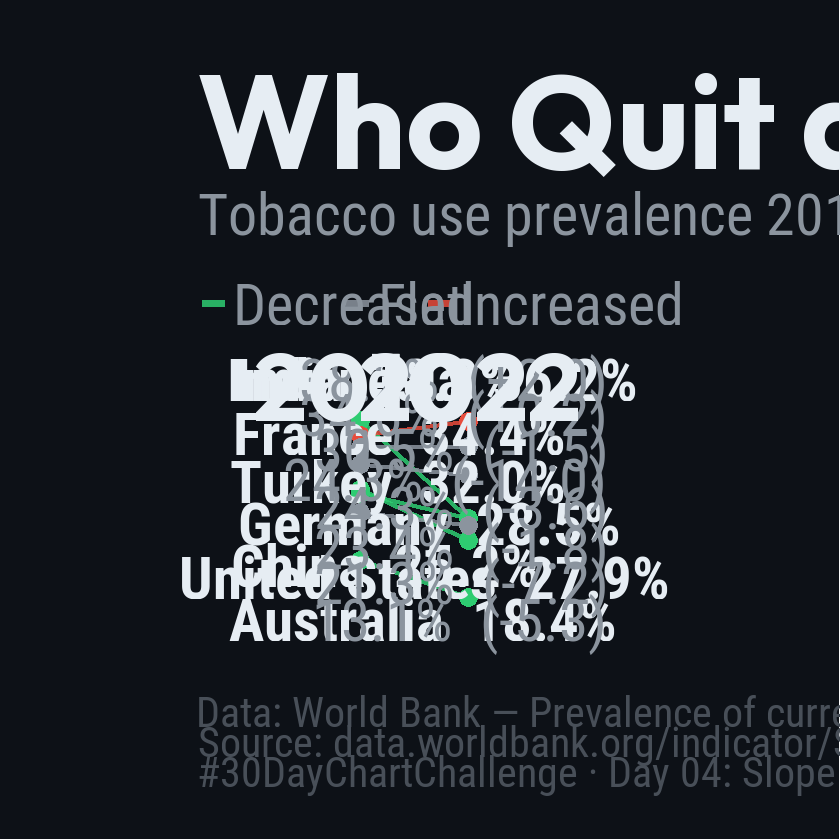

In [11]:
# — plot ----------------------------------------------------------------------

# x positions for the two years
x_left  <- 1
x_right <- 2

# format all values to 1 decimal place
df$lab_left  <- paste0(country = df$country, "  ", sprintf("%.1f", df$pct_2010), "%")
df$lab_right <- paste0(sprintf("%.1f", df$pct_2022), "%  (",
                       ifelse(df$change > 0, "+", ""),
                       sprintf("%.1f", df$change), ")")

p <- ggplot(df) +

  # connecting lines
  geom_segment(
    aes(x = x_left, xend = x_right,
        y = pct_2010, yend = pct_2022, color = trend),
    linewidth = 1.2, alpha = 0.85
  ) +

  # dots at each end
  geom_point(aes(x = x_left, y = pct_2010, color = trend),
             size = 5, show.legend = FALSE) +
  geom_point(aes(x = x_right, y = pct_2022, color = trend),
             size = 5, show.legend = FALSE) +

  # left labels
  geom_text_repel(
    aes(x = x_left, y = pct_2010, label = lab_left),
    hjust = 1, direction = "y", nudge_x = -0.08,
    segment.color = NA, seed = 42,
    color = txt, family = "roboto_condensed",
    fontface = "bold", size = 5
  ) +

  # right labels
  geom_text_repel(
    aes(x = x_right, y = pct_2022, label = lab_right),
    hjust = 0, direction = "y", nudge_x = 0.08,
    segment.color = NA, seed = 42,
    color = txt_dim, family = "roboto_condensed",
    size = 5
  ) +

  # year headers
  annotate("text", x = x_left, y = 43,
           label = "2010", color = txt, family = "outfit",
           fontface = "bold", size = 8) +
  annotate("text", x = x_right, y = 43,
           label = "2022", color = txt, family = "outfit",
           fontface = "bold", size = 8) +

  scale_color_manual(values = trend_colors, name = NULL) +
  scale_x_continuous(limits = c(-0.3, 3.4)) +
  scale_y_continuous(limits = c(8, 46)) +
  coord_cartesian(clip = "off") +

  labs(
    title    = "Who Quit and Who Didn't?",
    subtitle = paste0(
      "Tobacco use prevalence 2010 vs 2022 ",
      "\u00b7 Age-standardized, adults 15+"
    ),
    caption  = paste0(
      "Data: World Bank \u2014 Prevalence of current tobacco use ",
      "(% of adults), indicator SH.PRV.SMOK.\n",
      "Source: data.worldbank.org/indicator/SH.PRV.SMOK\n",
      "#30DayChartChallenge \u00b7 Day 04: Slope \u00b7 ",
      "Sharfudeen Yasar Arafath"
    )
  ) +

  theme_void(base_family = "roboto_condensed") +
  theme(
    plot.title       = element_text(family = "outfit", face = "bold", size = 32,
                                    hjust = 0, color = txt,
                                    margin = margin(t = 20, b = 8)),
    plot.subtitle    = element_text(size = 14, hjust = 0, color = txt_dim,
                                    margin = margin(b = 30)),
    plot.caption     = element_text(size = 10, hjust = 0, color = txt_cap,
                                    margin = margin(t = 30, b = 10),
                                    lineheight = 1.5),
    legend.position  = "top",
    legend.justification = "left",
    legend.text      = element_text(size = 14, color = txt_dim),
    legend.margin    = margin(b = 15),
    plot.background  = element_rect(fill = bg, color = NA),
    panel.background = element_rect(fill = bg, color = NA),
    plot.margin      = margin(25, 120, 20, 120)
  ) +
  guides(color = guide_legend(
    override.aes = list(linewidth = 2)
  ))

p

In [12]:
# — save ----------------------------------------------------------------------

ggsave("../../chart/day_04_slope.png",
       plot = p, width = 12, height = 12, dpi = 300, bg = bg)

cat("Done — saved to chart/day_04_slope.png\n")

Done — saved to chart/day_04_slope.png
